In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Demostración uso de técnicas de preprocesamiento en Pipeline

###1. Creamos datos sintéticos:
Los datos representan información ficticia sobre personas y sus hábitos de compra. Las variables son:


*   *Edad:* Edad de la persona (entre 18 y 70 años).
*   *Ingresos:* Ingresos anuales en una escala de 20,000 a 100,000 unidades monetarias.
*   *Categoria:* Categoría a la que pertenece la persona (A, B o C), según su caidad como cliente

In [32]:
np.random.seed(42)
edad = np.random.randint(18, 70, 300)
ingresos = 2000 * edad + np.random.normal(0, 5000, 300)
categoria = np.where(ingresos < np.percentile(ingresos, 33), 'A',
              np.where(ingresos < np.percentile(ingresos, 66), 'B', 'C'))

df = pd.DataFrame({'edad': edad, 'ingresos': ingresos, 'categoria': categoria})

In [33]:
df.head()

,edad,ingresos,categoria
0,56,111265.273035,C
1,69,138903.114869,C
2,46,96824.052912,B
3,32,58675.844236,A
4,60,120543.558998,C


In [34]:
X = df.drop(columns=['categoria'])
y_clas = df['categoria']  # target para realizar la regresión

#En principio queremos **predecir la variable categoria** en función de las otras variables. Es un problema de...?

###2. Separamos los datos en datos de entrenamiento y testeo

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_clas, y_test_clas = train_test_split(X, y_clas, test_size=0.2, random_state=42)

In [36]:
X_train.shape

(240, 2)

In [37]:
X_test.shape

(60, 2)

  ### 3. Armamos nuestro Pipeline  

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline para regresión lineal
classification_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clasificador', LogisticRegression())
])

# Entrenamiento de los modelos
classification_pipeline.fit(X_train, y_train_clas)


Pipeline(steps=[('scaler', StandardScaler()),
                ('clasificador', LogisticRegression())])

### 4. Obtenemos las predicciones del conjunto de entrenamiento y de testeo

In [39]:
y_pred_train= classification_pipeline.predict(X_train)
y_pred_test = classification_pipeline.predict(X_test)

### 5. Evaluamos nuestro modelo con la exactitud
podriamos usar otras metricas, por su puesto. En este caso la exactitud sirve ya que las clases están balanceadas y nos interesa clasificar a los clientes.

In [40]:
# Evaluación del modelo
train_score = classification_pipeline.score(X_train, y_train_clas)
test_score = classification_pipeline.score(X_test, y_test_clas)

print(f'Regresión Logística - Accuracy en Train: {train_score:.4f}')
print(f'Regresión Logística - Accuracy en Test: {test_score:.4f}')

Regresión Logística - Accuracy en Train: 0.9542
Regresión Logística - Accuracy en Test: 0.9833


### 6. Visualizamos como quedaron las separaciones de clases

In [41]:
classification_pipeline.named_steps['clasificador'].coef_

array([[-2.52292169, -3.33667746],
       [-0.02903495, -0.05131881],
       [ 2.55195664,  3.38799627]])

In [49]:
def visualize_classifier_new(model, X, y, ax=None, cmap='bwr', proba = False):
    if isinstance(X, pd.DataFrame):
        X = X.values
    if isinstance(y, pd.Series):
        y = y.values
    ax = ax or plt.gca()
    colors_tab10 = plt.cm.tab10.colors

    for i, y_value in enumerate(reversed(np.unique(y))):
        ax.scatter(X[y==y_value, 0], X[y==y_value, 1], s=30,
                   zorder=3, alpha = 0.5, color = colors_tab10[i])

    ax.axis('tight')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    # ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))

    if proba:
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)


    # Create a color plot with the results
    n_classes = len(np.unique(y))

    Z = -Z + 1

    ax.pcolormesh(xx,yy,Z,cmap=cmap, vmin = 0, vmax=1, alpha = 0.2)

    ax.set(xlim=xlim, ylim=ylim)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


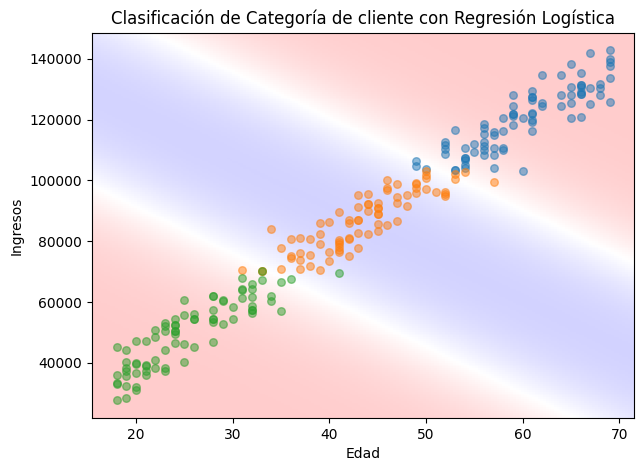

In [50]:
fig, axs = plt.subplots(1,1, figsize = (7,5))
visualize_classifier_new(classification_pipeline, X_train, y_train_clas, cmap = 'bwr', ax = axs, proba = True)
axs.set_xlabel('Edad')
axs.set_ylabel('Ingresos')
plt.title('Clasificación de Categoría de cliente con Regresión Logística')

plt.show()

# Ahora vamos a predecir la variable *ingresos* según las otras dos y vamos a sumar un atributo mas:
  *Compra:* Variable binaria (0 o 1) que indica si la persona realizó alguna compra o no.

En este caso, tenemos los siguientes atributos:


*   Edad:
*   Categoría:
*   Compra:

### Vamos a utilizar tranformación por columnas



In [20]:
df['compra'] = np.random.choice([0, 1], 300)
df.head()

,edad,ingresos,categoria,compra
0,56,111265.273035,C,1
1,69,138903.114869,C,1
2,46,96824.052912,B,1
3,32,58675.844236,A,0
4,60,120543.558998,C,0


In [23]:
X = df.drop(columns = ['ingresos'])
y_reg = df['ingresos']

### Hacemos un train-test split

In [24]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

### Hacemos una tranformación por columna

In [27]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = ['edad']
categorical_features = ['categoria', 'compra']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


### Pasamos un Pipeline para la regresión

In [28]:
from sklearn.linear_model import LinearRegression
regression_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regresor', LinearRegression())
])

regression_pipeline.fit(X_train, y_train_reg)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['edad']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['categoria', 'compra'])])),
                ('regresor', LinearRegression())])

### Vemos resultados de la regresión

In [29]:
regression_score_train = regression_pipeline.score(X_train, y_train_reg)
print(f'Regresión Lineal train - Accuracy: {regression_score_train:.4f}')

regression_score_test = regression_pipeline.score(X_test, y_test_reg)
print(f'Regresión Lineal test - Accuracy: {regression_score_test:.4f}')

Regresión Lineal train - Accuracy: 0.9723
Regresión Lineal test - Accuracy: 0.9770
